In [ ]:
import os
import tensorflow as tf
import kagglehub
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
base_path = kagglehub.dataset_download("kshitij192/cars-image-dataset")
train_dir = os.path.join(base_path, "train")
test_dir = os.path.join(base_path, "test")

for root, dirs, _ in os.walk(base_path):
    if "train" in dirs and "test" in dirs:
        train_dir = os.path.join(root, "train")
        test_dir = os.path.join(root, "test")
        break

if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"Папка 'train' не найдена по пути: {base_path}")

Using Colab cache for faster access to the 'cars-image-dataset' dataset.


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Train / Validation (20% на валидацию)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED,
    validation_split=0.2,
    subset="training",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED,
    validation_split=0.2,
    subset="validation",
    shuffle=True
)

# Test
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(f"Классы ({len(class_names)}): {class_names}")

Found 3352 files belonging to 7 classes.
Using 2682 files for training.
Found 3352 files belonging to 7 classes.
Using 670 files for validation.
Found 813 files belonging to 7 classes.
Классы (7): ['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']


In [ ]:
# Оптимизация конвейера
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    #1. СЛОЙ АУГМЕНТАЦИИ
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),          # ±0.2 рад (~11°)
    tf.keras.layers.RandomZoom(0.15),             # масштабирование ±15%
    tf.keras.layers.RandomContrast(0.2),          # изменение контраста ±20%

    #2. НОРМАЛИЗАЦИЯ (приводим пиксели к [0, 1])
    tf.keras.layers.Rescaling(1./255),

    #3. БЛОК ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ
    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    #4. КЛАССИФИКАТОР
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,231 (49.36 MB)

 Trainable params: 12,939,783 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
]

print("Запуск обучения...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Запуск обучения...
Epoch 1/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 521s 6s/step - accuracy: 0.2289 - loss: 1.9134 - val_accuracy: 0.1060 - val_loss: 43.4782 - learning_rate: 0.0010
Epoch 2/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 554s 6s/step - accuracy: 0.2189 - loss: 1.8967 - val_accuracy: 0.1896 - val_loss: 2.3506 - learning_rate: 0.0010
Epoch 3/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 511s 6s/step - accuracy: 0.2371 - loss: 1.8775 - val_accuracy: 0.2119 - val_loss: 1.9304 - learning_rate: 0.0010
Epoch 4/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 493s 6s/step - accuracy: 0.2487 - loss: 1.8706 - val_accuracy: 0.2075 - val_loss: 1.8709 - learning_rate: 0.0010
Epoch 5/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 501s 6s/step - accuracy: 0.2476 - loss: 1.8762 - val_accuracy: 0.2209 - val_loss: 1.8774 - learning_rate: 0.0010
Epoch 6/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2655 - loss: 1.8653
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
84/84 ━━━━━━━━━━━━━━━━━━━━ 499s 6s/step - accuracy: 0.2479 - loss:


Точность на тестовом наборе: 0.2423
Модель сохранена: /content/car_classifier.keras


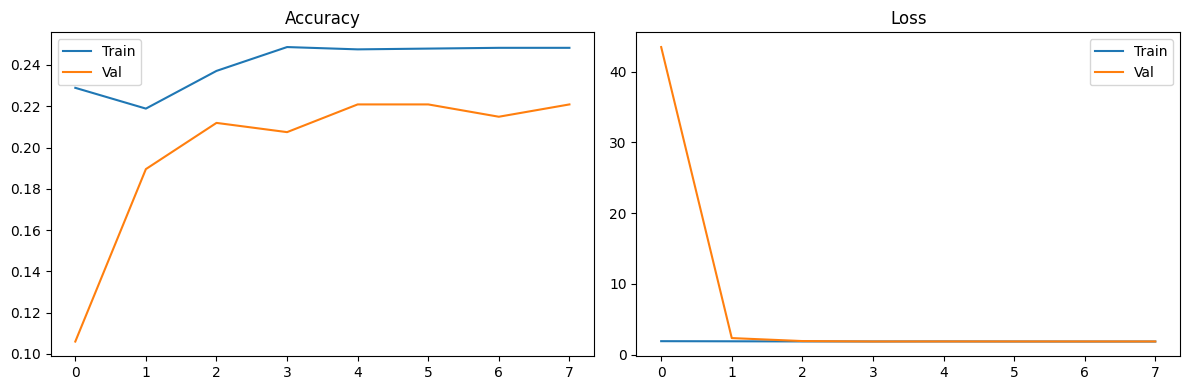

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nТочность на тестовом наборе: {test_acc:.4f}")

# Сохранение в формате .keras (совместим с Colab и локальным TF 2.x)
MODEL_PATH = "/content/car_classifier.keras"
model.save(MODEL_PATH)
print(f"Модель сохранена: {MODEL_PATH}")

# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()